Using device: cuda
Initial mean weight: 0.010629
Training...
Epoch 1/10, Accuracy: 0.1373, Mean Weight: 0.0053
Epoch 2/10, Accuracy: 0.1401, Mean Weight: 0.0053
Epoch 3/10, Accuracy: 0.1389, Mean Weight: 0.0053
Epoch 4/10, Accuracy: 0.1394, Mean Weight: 0.0053
Epoch 5/10, Accuracy: 0.1422, Mean Weight: 0.0053
Epoch 6/10, Accuracy: 0.1424, Mean Weight: 0.0053
Epoch 7/10, Accuracy: 0.1338, Mean Weight: 0.0053
Epoch 8/10, Accuracy: 0.1392, Mean Weight: 0.0053
Epoch 9/10, Accuracy: 0.1405, Mean Weight: 0.0053
Epoch 10/10, Accuracy: 0.1387, Mean Weight: 0.0053
Training finished in 494.02s
Testing...
Test Accuracy: 0.1291
Generating raster plot...


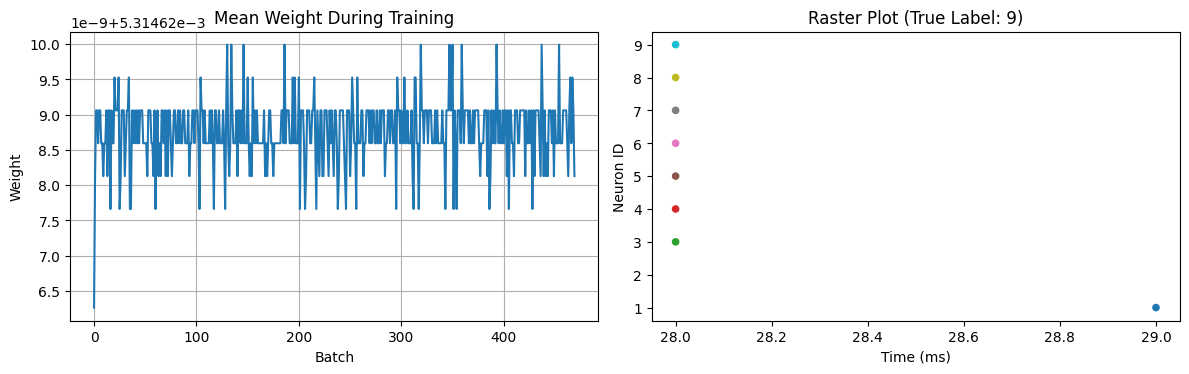


Final Accuracy: 0.1291
Model saved to snn_weights.pt


In [29]:
import torch
import numpy as np
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

############################################
# DATA
############################################

transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

batch_size = 64
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

############################################
# PARAMETERS
############################################

POP_NEURONS = 12
INPUT_NEURONS = 784 * POP_NEURONS
OUTPUT_NEURONS = 10
SIM_TIME = 50
EPOCHS = 10

############################################
# ENCODING
############################################

def population_encode(images):
    batch_size = images.shape[0]
    img_flat = (1.0 - images.view(batch_size, -1)).to(device)
    centers = torch.linspace(0, 1, POP_NEURONS, device=device)
    sigma = 0.25
    diff = img_flat.unsqueeze(-1) - centers.view(1, 1, -1)
    rates = torch.exp(-(diff ** 2) / (2 * sigma ** 2))
    return rates.view(batch_size, -1)

############################################
# SPIKE GENERATION
############################################

def generate_poisson_spikes(rates, sim_time, max_freq_hz=100):
    batch_size, n_inputs = rates.shape
    probs = torch.clamp(rates * (max_freq_hz / 1000.0), 0, 1)
    spikes = (torch.rand(sim_time, batch_size, n_inputs, device=device) < probs.unsqueeze(0)).float()
    return spikes

############################################
# LIF NETWORK (БЕЗ КЛАССА - ПРОЩЕ)
############################################

# Инициализация весов - БОЛЬШИЕ
weights = torch.abs(torch.randn(INPUT_NEURONS, OUTPUT_NEURONS, device=device) * 0.5)

# Нормализация: сумма весов = 100 (не 1!)
with torch.no_grad():
    weights = weights / weights.sum(dim=0, keepdims=True) * 100.0

print(f"Initial mean weight: {weights.mean().item():.6f}")

############################################
# LIF SIMULATION FUNCTION
############################################

def run_lif_batch(spikes, weights):
    """
    spikes: (Time, Batch, Inputs)
    weights: (Inputs, Outputs)
    """
    sim_time, batch_size, n_inputs = spikes.shape
    n_outputs = weights.shape[1]
    
    # Параметры
    tau_m, v_rest, v_thresh, v_reset = 20.0, -65.0, -50.0, -65.0
    r_m, tau_ref = 10.0, 2.0
    
    v = torch.full((batch_size, n_outputs), v_rest, device=device)
    refractory = torch.zeros((batch_size, n_outputs), device=device)
    spike_counts = torch.zeros((batch_size, n_outputs), device=device)
    
    for t in range(sim_time):
        # Ток: спайки @ веса
        currents = spikes[t] @ weights  # (Batch, Outputs)
        
        # Обновление потенциала
        dv = (-(v - v_rest) + r_m * currents) / tau_m
        v = v + dv
        
        # Проверка порога
        fired = (v >= v_thresh).float()
        
        # Сброс
        v = torch.where(fired.bool(), v_reset, v)
        refractory = torch.where(fired.bool(), torch.tensor(tau_ref, device=device), refractory)
        
        # Рефрактерность
        in_ref = (refractory > 0).bool()
        v = torch.where(in_ref, v_rest, v)
        refractory = torch.where(in_ref, refractory - 1, refractory)
        
        spike_counts += fired
    
    return spike_counts

############################################
# TRAINING
############################################

print("Training...")
start_time = time.time()
weight_history = []
learning_rate = 0.01

for epoch in range(EPOCHS):
    total_correct = 0
    total_samples = 0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        batch_size = images.shape[0]
        
        # Forward
        rates = population_encode(images)  # (Batch, Inputs)
        spikes = generate_poisson_spikes(rates, SIM_TIME)  # (Time, Batch, Inputs)
        spike_counts = run_lif_batch(spikes, weights)  # (Batch, Outputs)
        
        predictions = torch.argmax(spike_counts, dim=1)
        
        # Обучение
        with torch.no_grad():
            active_mask = (rates > 0.1).float()
            
            for b in range(batch_size):
                winner = predictions[b].item()
                true_label = labels[b].item()
                
                # Hebbian learning
                if winner == true_label:
                    # Усиливаем активные синапсы
                    weights[:, winner] += learning_rate * rates[b] * active_mask[b] * 10.0
                else:
                    # Ослабляем
                    weights[:, winner] -= learning_rate * rates[b] * active_mask[b] * 5.0
            
            # Ограничение весов [0.01, 10]
            weights = torch.clamp(weights, 0.01, 10.0)
            
            # Мягкая нормализация (не давим в 1, а держим в разумных пределах)
            col_sums = weights.sum(dim=0, keepdims=True)
            target_sum = 50.0  # Целевая сумма весов
            weights = weights / (col_sums + 1e-8) * target_sum
        
        total_correct += (predictions == labels).sum().item()
        total_samples += batch_size
        
        if batch_idx % 20 == 0:
            weight_history.append(weights.mean().item())
    
    acc = total_correct / total_samples
    print(f"Epoch {epoch+1}/{EPOCHS}, Accuracy: {acc:.4f}, Mean Weight: {weight_history[-1]:.4f}")

training_time = time.time() - start_time
print(f"Training finished in {training_time:.2f}s")

############################################
# TEST
############################################

print("Testing...")
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        rates = population_encode(images)
        spikes = generate_poisson_spikes(rates, SIM_TIME)
        spike_counts = run_lif_batch(spikes, weights)
        
        predictions = torch.argmax(spike_counts, dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print(f"Test Accuracy: {accuracy:.4f}")

############################################
# RASTER PLOT
############################################

print("Generating raster plot...")
image, label = test_dataset[0]
image = image.unsqueeze(0).to(device)

rates = population_encode(image)
spikes = generate_poisson_spikes(rates, SIM_TIME)

# Запуск для растра
v = torch.full((1, OUTPUT_NEURONS), -65.0, device=device)
refractory = torch.zeros((1, OUTPUT_NEURONS), device=device)

spike_times = []
spike_neurons = []

for t in range(SIM_TIME):
    currents = spikes[t] @ weights
    dv = (-(v - -65.0) + 10.0 * currents) / 20.0
    v = v + dv
    
    fired = (v >= -50.0).bool()
    v = torch.where(fired, torch.tensor(-65.0, device=device), v)
    refractory = torch.where(fired, torch.tensor(2.0, device=device), refractory)
    
    in_ref = (refractory > 0).bool()
    v = torch.where(in_ref, torch.tensor(-65.0, device=device), v)
    refractory = torch.where(in_ref, refractory - 1, refractory)
    
    if fired.any():
        for n in range(OUTPUT_NEURONS):
            if fired[0, n]:
                spike_times.append(t)
                spike_neurons.append(n)

############################################
# PLOTS
############################################

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(weight_history)
plt.title("Mean Weight During Training")
plt.xlabel("Batch")
plt.ylabel("Weight")
plt.grid(True)

plt.subplot(1, 2, 2)
if spike_times:
    plt.scatter(spike_times, spike_neurons, s=20, c=spike_neurons, cmap='tab10')
    plt.title(f"Raster Plot (True Label: {label})")
else:
    plt.text(0.5, 0.5, "No spikes!", ha='center', va='center', fontsize=12)
    plt.title("Raster Plot - EMPTY")
plt.xlabel("Time (ms)")
plt.ylabel("Neuron ID")
plt.tight_layout()
plt.show()

print(f"\nFinal Accuracy: {accuracy:.4f}")


torch.save({
    'weights': weights,
    'pop_neurons': POP_NEURONS,
    'sim_time': SIM_TIME
}, 'snn_weights.pt')
print("Model saved to snn_weights.pt")

Using device: cuda
Initial mean weight: 0.005315
Training...
Epoch 1/15, Accuracy: 0.4038, Time: 105.2s
Epoch 2/15, Accuracy: 0.4075, Time: 106.6s
Epoch 3/15, Accuracy: 0.4048, Time: 125.0s
Epoch 4/15, Accuracy: 0.4067, Time: 116.2s
Epoch 5/15, Accuracy: 0.4079, Time: 109.1s
Epoch 6/15, Accuracy: 0.4035, Time: 108.7s
Epoch 7/15, Accuracy: 0.4072, Time: 107.2s
Epoch 8/15, Accuracy: 0.4083, Time: 108.4s
Epoch 9/15, Accuracy: 0.4044, Time: 108.8s
Epoch 10/15, Accuracy: 0.4058, Time: 116.0s
Epoch 11/15, Accuracy: 0.4067, Time: 115.8s
Epoch 12/15, Accuracy: 0.4049, Time: 119.1s
Epoch 13/15, Accuracy: 0.4027, Time: 127.5s
Epoch 14/15, Accuracy: 0.4057, Time: 121.8s
Epoch 15/15, Accuracy: 0.4073, Time: 121.2s
Training finished in 1716.63s
Testing...
Test Accuracy: 0.3160
Model saved to snn_weights.pt
Generating raster plot...


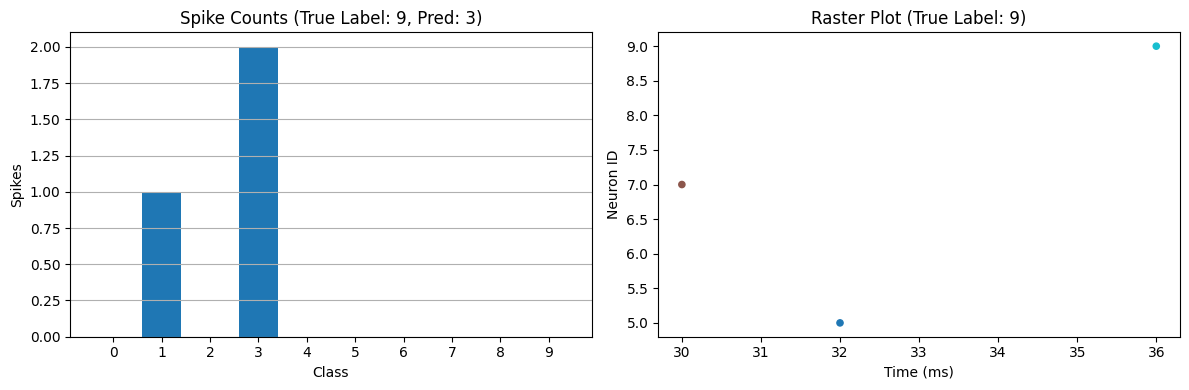


Final Accuracy: 0.3160


In [22]:
import torch
import numpy as np
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

############################################
# DATA
############################################

transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

batch_size = 64
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

############################################
# PARAMETERS
############################################

POP_NEURONS = 12
INPUT_NEURONS = 784 * POP_NEURONS
OUTPUT_NEURONS = 10
SIM_TIME = 50
EPOCHS = 15  # Увеличил для лучшего обучения

############################################
# ENCODING
############################################

def population_encode(images):
    batch_size = images.shape[0]
    img_flat = (1.0 - images.view(batch_size, -1)).to(device)
    centers = torch.linspace(0, 1, POP_NEURONS, device=device)
    sigma = 0.25
    diff = img_flat.unsqueeze(-1) - centers.view(1, 1, -1)
    rates = torch.exp(-(diff ** 2) / (2 * sigma ** 2))
    return rates.view(batch_size, -1)

############################################
# SPIKE GENERATION
############################################

def generate_poisson_spikes(rates, sim_time, max_freq_hz=100):
    batch_size, n_inputs = rates.shape
    probs = torch.clamp(rates * (max_freq_hz / 1000.0), 0, 1)
    spikes = (torch.rand(sim_time, batch_size, n_inputs, device=device) < probs.unsqueeze(0)).float()
    return spikes

############################################
# LIF NETWORK
############################################

# Инициализация весов
weights = torch.abs(torch.randn(INPUT_NEURONS, OUTPUT_NEURONS, device=device) * 0.5)

# Нормализация при старте
with torch.no_grad():
    weights = weights / weights.sum(dim=0, keepdims=True) * 50.0  # Уменьшил с 100 до 50

print(f"Initial mean weight: {weights.mean().item():.6f}")

############################################
# LIF SIMULATION FUNCTION
############################################

def run_lif_batch(spikes, weights):
    sim_time, batch_size, n_inputs = spikes.shape
    n_outputs = weights.shape[1]
    
    tau_m, v_rest, v_thresh, v_reset = 20.0, -65.0, -50.0, -65.0
    r_m, tau_ref = 10.0, 2.0
    
    v = torch.full((batch_size, n_outputs), v_rest, device=device)
    refractory = torch.zeros((batch_size, n_outputs), device=device)
    spike_counts = torch.zeros((batch_size, n_outputs), device=device)
    
    for t in range(sim_time):
        currents = spikes[t] @ weights
        dv = (-(v - v_rest) + r_m * currents) / tau_m
        v = v + dv
        
        fired = (v >= v_thresh).float()
        v = torch.where(fired.bool(), v_reset, v)
        refractory = torch.where(fired.bool(), torch.tensor(tau_ref, device=device), refractory)
        
        in_ref = (refractory > 0).bool()
        v = torch.where(in_ref, v_rest, v)
        refractory = torch.where(in_ref, refractory - 1, refractory)
        
        spike_counts += fired
    
    return spike_counts

############################################
# TRAINING
############################################

print("Training...")
start_time = time.time()
learning_rate = 0.05  # Увеличил с 0.01 до 0.05

for epoch in range(EPOCHS):
    total_correct = 0
    total_samples = 0
    epoch_start = time.time()
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        bs = images.shape[0]
        
        # Forward
        rates = population_encode(images)
        spikes = generate_poisson_spikes(rates, SIM_TIME)
        spike_counts = run_lif_batch(spikes, weights)
        
        predictions = torch.argmax(spike_counts, dim=1)
        
        # Обучение
        with torch.no_grad():
            active_mask = (rates > 0.1).float()
            
            for b in range(bs):
                true_label = labels[b].item()  # Берем ПРАВИЛЬНЫЙ класс
                
                # Усиливаем синапсы для правильного класса (Supervised Hebbian)
                weights[:, true_label] += learning_rate * rates[b] * active_mask[b] * 5.0
                
                # Слабое ослабление для остальных (конкуренция)
                for other in range(OUTPUT_NEURONS):
                    if other != true_label:
                        weights[:, other] -= learning_rate * rates[b] * active_mask[b] * 0.5
            
            # Ограничение весов
            weights = torch.clamp(weights, 0.01, 5.0)
            
            # Мягкая нормализация
            col_sums = weights.sum(dim=0, keepdims=True)
            target_sum = 30.0  # Уменьшил с 50 до 30
            weights = weights / (col_sums + 1e-8) * target_sum
        
        total_correct += (predictions == labels).sum().item()
        total_samples += bs
    
    epoch_time = time.time() - epoch_start
    acc = total_correct / total_samples
    print(f"Epoch {epoch+1}/{EPOCHS}, Accuracy: {acc:.4f}, Time: {epoch_time:.1f}s")

training_time = time.time() - start_time
print(f"Training finished in {training_time:.2f}s")

############################################
# TEST
############################################

print("Testing...")
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        rates = population_encode(images)
        spikes = generate_poisson_spikes(rates, SIM_TIME)
        spike_counts = run_lif_batch(spikes, weights)
        
        predictions = torch.argmax(spike_counts, dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print(f"Test Accuracy: {accuracy:.4f}")

############################################
# SAVE MODEL
############################################

torch.save({
    'weights': weights,
    'pop_neurons': POP_NEURONS,
    'sim_time': SIM_TIME
}, 'snn_weights.pt')
print("Model saved to snn_weights.pt")

############################################
# RASTER PLOT
############################################

print("Generating raster plot...")
image, label = test_dataset[0]
image = image.unsqueeze(0).to(device)

rates = population_encode(image)
spikes = generate_poisson_spikes(rates, SIM_TIME)

v = torch.full((1, OUTPUT_NEURONS), -65.0, device=device)
refractory = torch.zeros((1, OUTPUT_NEURONS), device=device)

spike_times = []
spike_neurons = []

for t in range(SIM_TIME):
    currents = spikes[t] @ weights
    dv = (-(v - -65.0) + 10.0 * currents) / 20.0
    v = v + dv
    
    fired = (v >= -50.0).bool()
    v = torch.where(fired, torch.tensor(-65.0, device=device), v)
    refractory = torch.where(fired, torch.tensor(2.0, device=device), refractory)
    
    in_ref = (refractory > 0).bool()
    v = torch.where(in_ref, torch.tensor(-65.0, device=device), v)
    refractory = torch.where(in_ref, refractory - 1, refractory)
    
    if fired.any():
        for n in range(OUTPUT_NEURONS):
            if fired[0, n]:
                spike_times.append(t)
                spike_neurons.append(n)

############################################
# PLOTS
############################################

plt.figure(figsize=(12, 4))

# График точности по эпохам (вместо весов)
plt.subplot(1, 2, 1)
plt.bar(range(10), spike_counts[0].cpu().numpy())
plt.xticks(range(10))
plt.title(f"Spike Counts (True Label: {label}, Pred: {predictions[0].item()})")
plt.xlabel("Class")
plt.ylabel("Spikes")
plt.grid(axis='y')

plt.subplot(1, 2, 2)
if spike_times:
    plt.scatter(spike_times, spike_neurons, s=20, c=spike_neurons, cmap='tab10')
    plt.title(f"Raster Plot (True Label: {label})")
else:
    plt.text(0.5, 0.5, "No spikes!", ha='center', va='center', fontsize=12)
    plt.title("Raster Plot - EMPTY")
plt.xlabel("Time (ms)")
plt.ylabel("Neuron ID")
plt.tight_layout()
plt.show()

print(f"\nFinal Accuracy: {accuracy:.4f}")

Loading model from 40-30min.pt...
Model loaded. Device: cuda

Processing: tshirt.png

Prediction: Trouser (Class 1)
Confidence: 2.00% (1/50 spikes)



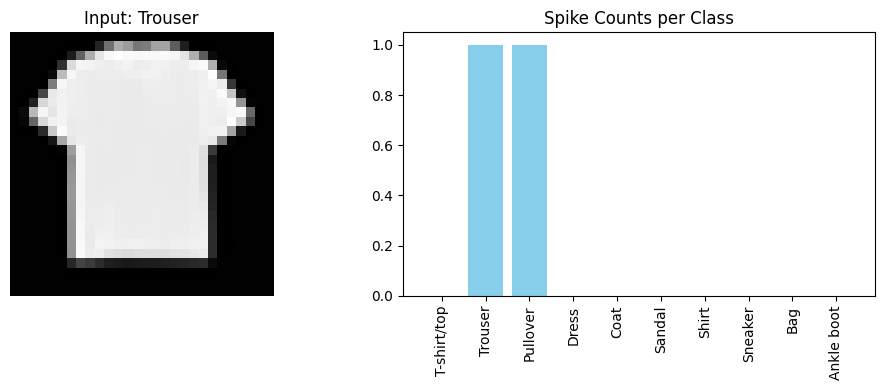


Processing: sneaker.png

Prediction: Trouser (Class 1)
Confidence: 2.00% (1/50 spikes)



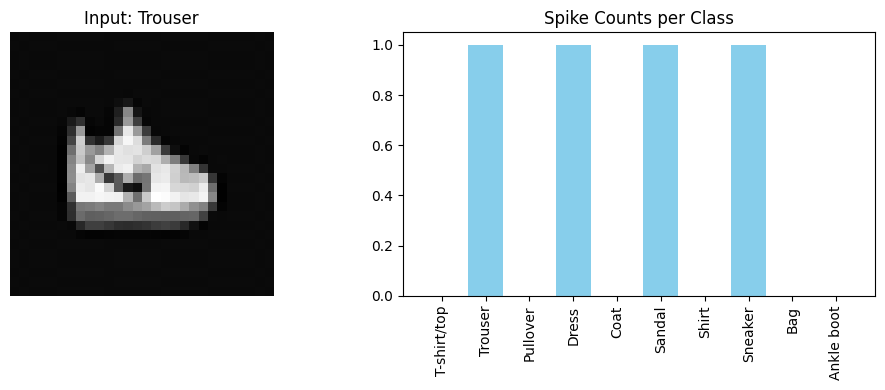


Processing: dress.png

Prediction: Trouser (Class 1)
Confidence: 2.00% (1/50 spikes)



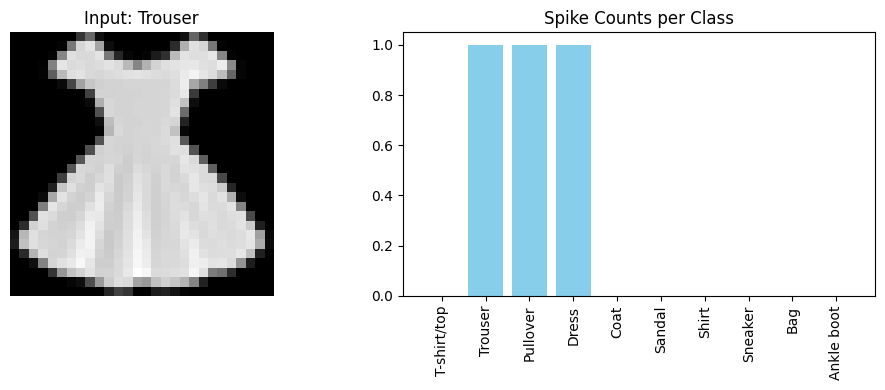


Processing: coat.jpg

Prediction: Pullover (Class 2)
Confidence: 4.00% (2/50 spikes)



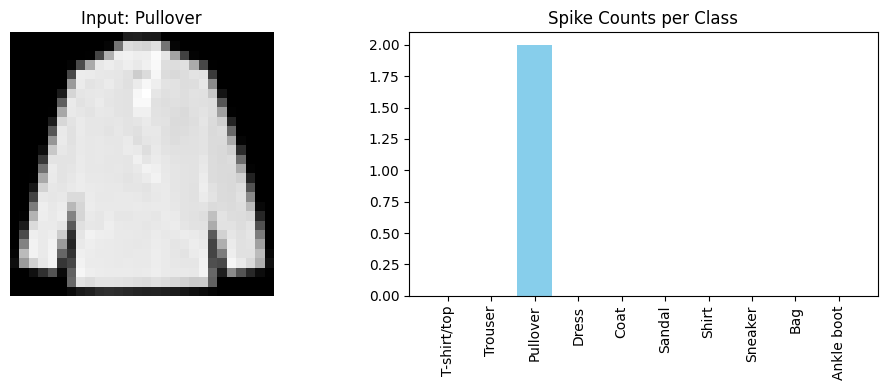


Processing: pullover.jpg

Prediction: Pullover (Class 2)
Confidence: 4.00% (2/50 spikes)



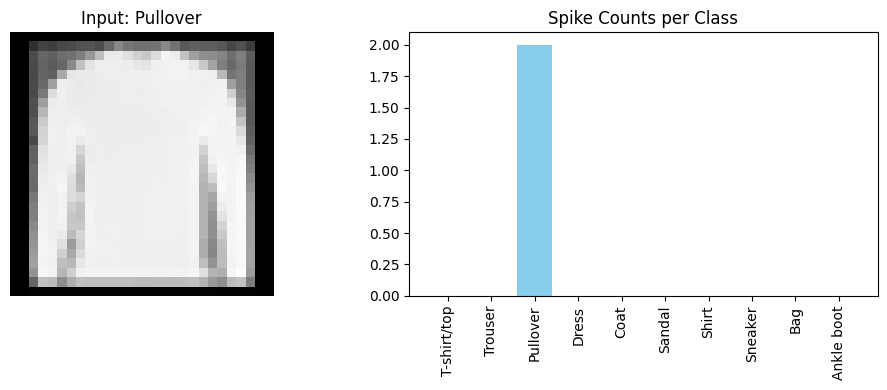


Processing: sandal.jpg

Prediction: Sneaker (Class 7)
Confidence: 2.00% (1/50 spikes)



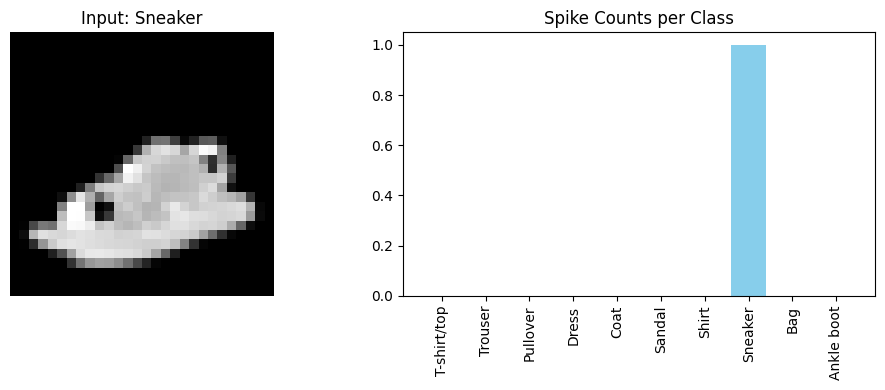


Processing: bag.jpg

Prediction: Trouser (Class 1)
Confidence: 2.00% (1/50 spikes)



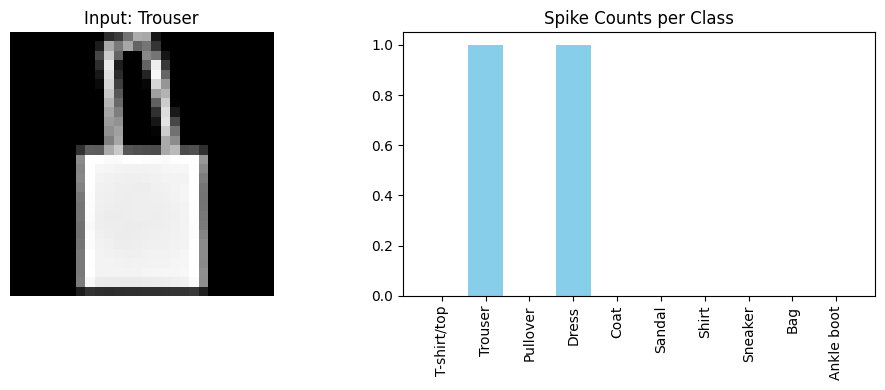


Processing: ankle.jpg

Prediction: T-shirt/top (Class 0)
Confidence: 0.00% (0/50 spikes)



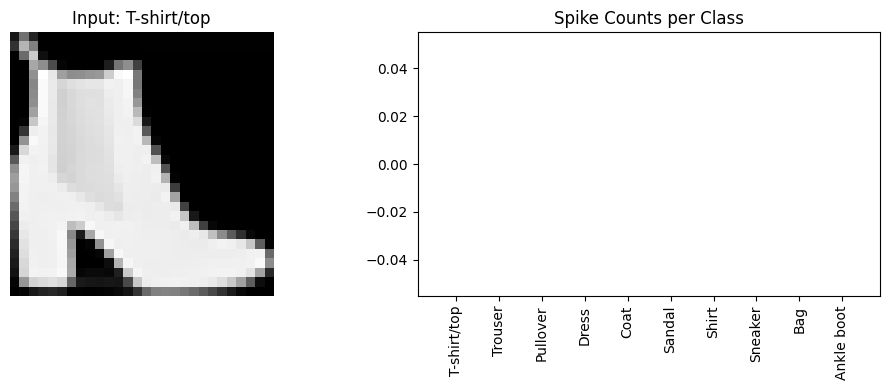


Processing: trouser.png

Prediction: Trouser (Class 1)
Confidence: 2.00% (1/50 spikes)



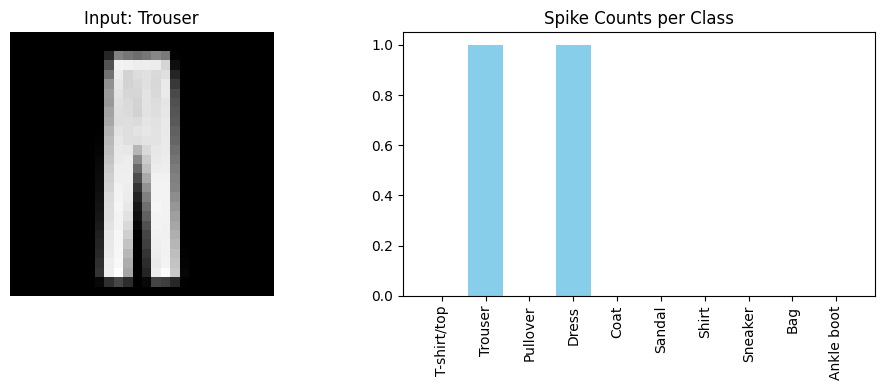


Processing: shirt.png

Prediction: Pullover (Class 2)
Confidence: 2.00% (1/50 spikes)



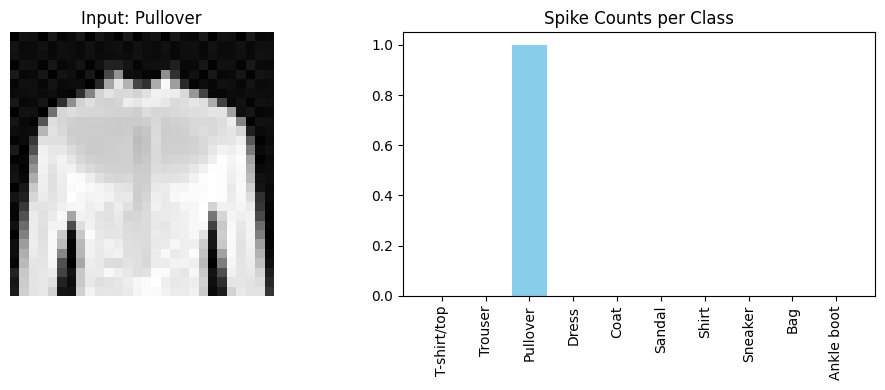

In [36]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import sys
import os

# ==========================================
# КОНФИГУРАЦИЯ
# ==========================================

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_PATH = '40-30min.pt'  # Файл с весами
IMAGE_PATH = 'my_image.png'    # Путь к вашему изображению

CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# ==========================================
# ЗАГРУЗКА МОДЕЛИ
# ==========================================

print(f"Loading model from {MODEL_PATH}...")
if not os.path.exists(MODEL_PATH):
    print("Error: Model file not found! Run training first.")
    sys.exit(1)

checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
weights = checkpoint['weights'].to(DEVICE)
POP_NEURONS = checkpoint['pop_neurons']
SIM_TIME = checkpoint['sim_time']

INPUT_NEURONS = 784 * POP_NEURONS
OUTPUT_NEURONS = 10

print(f"Model loaded. Device: {DEVICE}")

# ==========================================
# ФУНКЦИИ СЕТИ
# ==========================================

def population_encode(images):
    batch_size = images.shape[0]
    img_flat = (1.0 - images.view(batch_size, -1)).to(DEVICE)
    centers = torch.linspace(0, 1, POP_NEURONS, device=DEVICE)
    sigma = 0.25
    diff = img_flat.unsqueeze(-1) - centers.view(1, 1, -1)
    rates = torch.exp(-(diff ** 2) / (2 * sigma ** 2))
    return rates.view(batch_size, -1)

def generate_poisson_spikes(rates, sim_time, max_freq_hz=100):
    batch_size, n_inputs = rates.shape
    probs = torch.clamp(rates * (max_freq_hz / 1000.0), 0, 1)
    spikes = (torch.rand(sim_time, batch_size, n_inputs, device=DEVICE) < probs.unsqueeze(0)).float()
    return spikes

def run_lif(spikes, weights):
    sim_time, batch_size, _ = spikes.shape
    n_outputs = weights.shape[1]
    
    v = torch.full((batch_size, n_outputs), -65.0, device=DEVICE)
    refractory = torch.zeros((batch_size, n_outputs), device=DEVICE)
    spike_counts = torch.zeros((batch_size, n_outputs), device=DEVICE)
    
    for t in range(sim_time):
        currents = spikes[t] @ weights
        dv = (-(v - -65.0) + 10.0 * currents) / 20.0
        v = v + dv
        fired = (v >= -50.0).float()
        v = torch.where(fired.bool(), -65.0, v)
        refractory = torch.where(fired.bool(), torch.tensor(2.0, device=DEVICE), refractory)
        in_ref = (refractory > 0).bool()
        v = torch.where(in_ref, -65.0, v)
        refractory = torch.where(in_ref, refractory - 1, refractory)
        spike_counts += fired
    
    return spike_counts

# ==========================================
# ПРЕДОБРАБОТКА ИЗОБРАЖЕНИЯ
# ==========================================

def preprocess_image(path):
    img = Image.open(path).convert('L')  # Чёрно-белое
    img = img.resize((28, 28))           # Размер FashionMNIST
    
    # Инверсия (фон чёрный, объект белый)
    img_array = np.array(img)
    img_array = 255 - img_array          
    img_array = img_array / 255.0        # Нормализация 0-1
    
    tensor = torch.FloatTensor(img_array).unsqueeze(0).unsqueeze(0)
    return tensor.to(DEVICE), img_array

# ==========================================
# ПРЕДСКАЗАНИЕ
# ==========================================

def predict(image_path):
    print(f"\nProcessing: {image_path}")
    
    if not os.path.exists(image_path):
        print("Error: Image file not found!")
        return
    
    # 1. Подготовка
    tensor, img_array = preprocess_image(image_path)
    
    # 2. Кодирование
    rates = population_encode(tensor)
    
    # 3. Генерация спайков
    spikes = generate_poisson_spikes(rates, SIM_TIME)
    
    # 4. Прогон сети
    with torch.no_grad():
        spike_counts = run_lif(spikes, weights)
        prediction = torch.argmax(spike_counts, dim=1).item()
        confidence = spike_counts[0, prediction].item() / SIM_TIME
    
    # 5. Результат
    class_name = CLASS_NAMES[prediction]
    print(f"\n{'='*40}")
    print(f"Prediction: {class_name} (Class {prediction})")
    print(f"Confidence: {confidence:.2%} ({int(confidence*SIM_TIME)}/{SIM_TIME} spikes)")
    print(f"{'='*40}\n")
    
    # 6. Визуализация
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img_array, cmap='gray')
    plt.title(f"Input: {class_name}")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.bar(CLASS_NAMES, spike_counts[0].cpu().numpy(), color='skyblue')
    plt.xticks(rotation=90)
    plt.title("Spike Counts per Class")
    plt.tight_layout()
    plt.show()

# ==========================================
# ЗАПУСК
# ==========================================

    
predict("tshirt.png")
predict("sneaker.png")
predict("dress.png")
predict("coat.jpg")
predict("pullover.jpg")
predict("sandal.jpg")
predict("bag.jpg")
predict("ankle.jpg")
predict("trouser.png")
predict("shirt.png")